# NB01 — Data Collection

**Project**: Camino de Santiago — Contextual Drivers of Pilgrim Flow Mutations (2003–2025)  
**Phase**: Data collection — Tier 1 sources  

---

## Collection roadmap

| Section | Source | Method | Status |
|---------|--------|--------|--------|
| 1 | Google Trends | pytrends API | ✅ Active |
| 2 | Oficina del Peregrino | PDF extraction | 🔲 Pending |
| 3 | Bureau SJPDP (Saint-Jean-Pied-de-Port) | PDF / manual | 🔲 Pending |
| 4 | Trail du Saint-Jacques | LiveTrail scraping | 🔲 Pending |
| 5 | ERA5 Climate data | cdsapi | 🔲 Pending |

> Raw files saved to `data/raw/` — never modify them.  
> Processed outputs saved to `data/processed/`.

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = Path('..').resolve()
RAW          = PROJECT_ROOT / 'data' / 'raw'
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
EXTERNAL     = PROJECT_ROOT / 'data' / 'external'

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

print("Setup OK")
print(f"RAW      → {RAW}")
print(f"PROCESSED → {PROCESSED}")

Setup OK
RAW      → C:\Users\cello\Desktop\camino_datascience\data\raw
PROCESSED → C:\Users\cello\Desktop\camino_datascience\data\processed


---
## Section 1 — Google Trends

**Objective**: Build a digital visibility index per country and year for Camino-related searches.

**Strategy**:
- Query one keyword per language/country to capture native search behaviour
- Collect annual series 2004–2024 (Google Trends starts in 2004)
- Use `timeframe='all'` for the full series, then monthly for detail
- Respect rate limits: 1-second pause between requests

**Known limitation**: Google Trends returns a relative index (0–100), not absolute volumes.  
Interpretation: values are comparable *within* a country over time, not *across* countries.

### 1.1 Keywords by country

In [2]:
# Keywords — one dominant term per country/language
# Format: { 'country_code': ('keyword', 'language_label') }

KEYWORDS = {
    'ES': ('Camino de Santiago',      'Spanish'),
    'FR': ('chemin de Compostelle',   'French'),
    'DE': ('Jakobsweg',               'German'),
    'IT': ('Cammino di Santiago',     'Italian'),
    'US': ('Camino de Santiago',      'English-US'),
    'GB': ('Camino de Santiago',      'English-UK'),
    'PT': ('Caminho de Santiago',     'Portuguese'),
    'KR': ('산티아고 순례길',            'Korean'),
    'BR': ('Caminho de Santiago',     'Portuguese-BR'),
}

print(f"{len(KEYWORDS)} countries configured:")
for code, (kw, lang) in KEYWORDS.items():
    print(f"  {code} | {lang:<15} | '{kw}'")

9 countries configured:
  ES | Spanish         | 'Camino de Santiago'
  FR | French          | 'chemin de Compostelle'
  DE | German          | 'Jakobsweg'
  IT | Italian         | 'Cammino di Santiago'
  US | English-US      | 'Camino de Santiago'
  GB | English-UK      | 'Camino de Santiago'
  PT | Portuguese      | 'Caminho de Santiago'
  KR | Korean          | '산티아고 순례길'
  BR | Portuguese-BR   | 'Caminho de Santiago'


### 1.2 Collect annual trends (2004–2024)

In [6]:
from pytrends.request import TrendReq

# Fix for urllib3 >= 2.0 compatibility issue (method_whitelist → allowed_methods)
pytrends = TrendReq(
    hl='en-US',
    tz=0
)

print("pytrends initialised")

pytrends initialised


In [4]:
def fetch_trends_country(keyword, geo, timeframe='2004-01-01 2024-12-31'):
    """
    Fetch Google Trends interest-over-time for one keyword in one country.
    
    Returns a DataFrame with columns: [date, interest, keyword, geo]
    Returns None if the request fails.
    """
    try:
        pytrends.build_payload(
            kw_list=[keyword],
            geo=geo,
            timeframe=timeframe
        )
        df = pytrends.interest_over_time()

        if df.empty:
            print(f"  ⚠ No data returned for {geo} — '{keyword}'")
            return None

        df = df.reset_index()[['date', keyword]]
        df.columns = ['date', 'interest']
        df['keyword'] = keyword
        df['geo']     = geo
        return df

    except Exception as e:
        print(f"  ✗ Error for {geo}: {e}")
        return None


print("Function defined — ready to collect")

Function defined — ready to collect


In [7]:
# --- MAIN COLLECTION LOOP ---
# Runtime: ~2-3 minutes (1 request per country + 2s pause)
# If a country fails, it is skipped and logged — collection continues.

all_trends = []
failed     = []

for geo, (keyword, lang) in KEYWORDS.items():
    print(f"Fetching {geo} ({lang}) — '{keyword}' ...", end=' ')
    df = fetch_trends_country(keyword, geo)

    if df is not None:
        all_trends.append(df)
        print(f"✓  {len(df)} rows")
    else:
        failed.append(geo)

    time.sleep(2)  # Respect Google rate limit

print(f"\nCollection complete: {len(all_trends)}/{len(KEYWORDS)} countries")
if failed:
    print(f"Failed: {failed} — retry manually below")

Fetching ES (Spanish) — 'Camino de Santiago' ... ✓  252 rows
Fetching FR (French) — 'chemin de Compostelle' ... ✓  252 rows
Fetching DE (German) — 'Jakobsweg' ... ✓  252 rows
Fetching IT (Italian) — 'Cammino di Santiago' ...   ✗ Error for IT: The request failed: Google returned a response with code 429
Fetching US (English-US) — 'Camino de Santiago' ...   ✗ Error for US: The request failed: Google returned a response with code 429
Fetching GB (English-UK) — 'Camino de Santiago' ... ✓  252 rows
Fetching PT (Portuguese) — 'Caminho de Santiago' ... ✓  252 rows
Fetching KR (Korean) — '산티아고 순례길' ... ✓  252 rows
Fetching BR (Portuguese-BR) — 'Caminho de Santiago' ... ✓  252 rows

Collection complete: 7/9 countries
Failed: ['IT', 'US'] — retry manually below


In [8]:
# Retry failed countries
retry_countries = ['IT', 'US']

for geo in retry_countries:
    keyword, lang = KEYWORDS[geo]
    print(f"Retrying {geo} ({lang}) — '{keyword}' ...", end=' ')
    df = fetch_trends_country(keyword, geo)
    
    if df is not None:
        all_trends.append(df)
        if geo in failed:
            failed.remove(geo)
        print(f"✓  {len(df)} rows")
    else:
        print(f"✗ still failing")
    
    time.sleep(5)  # Plus long cette fois

print(f"\nFailed remaining: {failed}")

Retrying IT (Italian) — 'Cammino di Santiago' ... ✓  252 rows
Retrying US (English-US) — 'Camino de Santiago' ... ✓  252 rows

Failed remaining: []


In [9]:
# Consolidate into a single DataFrame
trends_raw = pd.concat(all_trends, ignore_index=True)
trends_raw['date'] = pd.to_datetime(trends_raw['date'])
trends_raw['year'] = trends_raw['date'].dt.year

print(f"Shape: {trends_raw.shape}")
print(f"Date range: {trends_raw['date'].min().date()} → {trends_raw['date'].max().date()}")
print(f"Countries: {sorted(trends_raw['geo'].unique())}")
trends_raw.head()

Shape: (2268, 5)
Date range: 2004-01-01 → 2024-12-01
Countries: ['BR', 'DE', 'ES', 'FR', 'GB', 'IT', 'KR', 'PT', 'US']


,date,interest,keyword,geo,year
0,2004-01-01,86,Camino de Santiago,ES,2004
1,2004-02-01,89,Camino de Santiago,ES,2004
2,2004-03-01,82,Camino de Santiago,ES,2004
3,2004-04-01,87,Camino de Santiago,ES,2004
4,2004-05-01,91,Camino de Santiago,ES,2004


In [10]:
# Save raw output
raw_path = RAW / 'trends_raw_2004_2024.csv'
trends_raw.to_csv(raw_path, index=False)
print(f"Saved → {raw_path}")

Saved → C:\Users\cello\Desktop\camino_datascience\data\raw\trends_raw_2004_2024.csv


### 1.3 Build annual index

In [11]:
# Aggregate to annual mean interest per country
trends_annual = (
    trends_raw
    .groupby(['geo', 'year'])['interest']
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={'interest': 'interest_mean'})
)

# Add language label
lang_map = {geo: lang for geo, (_, lang) in KEYWORDS.items()}
trends_annual['language'] = trends_annual['geo'].map(lang_map)

print(f"Annual index shape: {trends_annual.shape}")
trends_annual.head(10)

Annual index shape: (189, 4)


,geo,year,interest_mean,language
0,BR,2004,61.67,Portuguese-BR
1,BR,2005,50.25,Portuguese-BR
2,BR,2006,42.83,Portuguese-BR
3,BR,2007,29.92,Portuguese-BR
4,BR,2008,21.50,Portuguese-BR
5,BR,2009,21.58,Portuguese-BR
6,BR,2010,19.33,Portuguese-BR
7,BR,2011,18.83,Portuguese-BR
8,BR,2012,17.50,Portuguese-BR
9,BR,2013,17.75,Portuguese-BR


In [12]:
# Save processed annual index
proc_path = PROCESSED / 'trends_annual.csv'
trends_annual.to_csv(proc_path, index=False)
print(f"Saved → {proc_path}")

Saved → C:\Users\cello\Desktop\camino_datascience\data\processed\trends_annual.csv


### 1.4 Visualisation

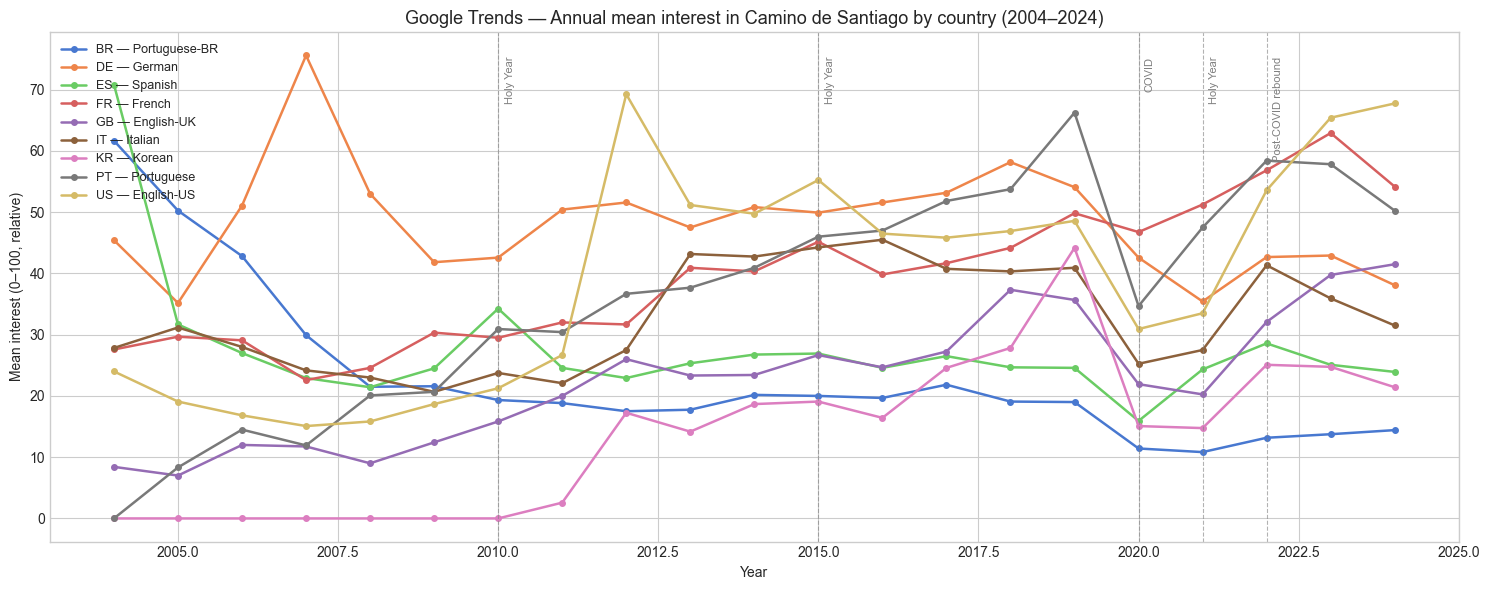

Figure saved → C:\Users\cello\Desktop\camino_datascience\reports\trends_annual_by_country.png


In [13]:
# Plot annual trends per country
countries = trends_annual['geo'].unique()
palette   = sns.color_palette('muted', len(countries))

fig, ax = plt.subplots(figsize=(15, 6))

for i, geo in enumerate(sorted(countries)):
    subset = trends_annual[trends_annual['geo'] == geo]
    ax.plot(
        subset['year'],
        subset['interest_mean'],
        marker='o', markersize=4,
        linewidth=1.8,
        label=f"{geo} — {lang_map[geo]}",
        color=palette[i]
    )

# Mark key events
events = {
    2010: 'Holy Year',
    2015: 'Holy Year',
    2020: 'COVID',
    2021: 'Holy Year',
    2022: 'Post-COVID rebound'
}
for yr, label in events.items():
    ax.axvline(x=yr, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(yr + 0.1, ax.get_ylim()[1] * 0.95, label,
            fontsize=8, color='gray', rotation=90, va='top')

ax.set_title('Google Trends — Annual mean interest in Camino de Santiago by country (2004–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Mean interest (0–100, relative)')
ax.legend(loc='upper left', fontsize=9, framealpha=0.7)
plt.tight_layout()

fig_path = PROJECT_ROOT / 'reports' / 'trends_annual_by_country.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Figure saved → {fig_path}")

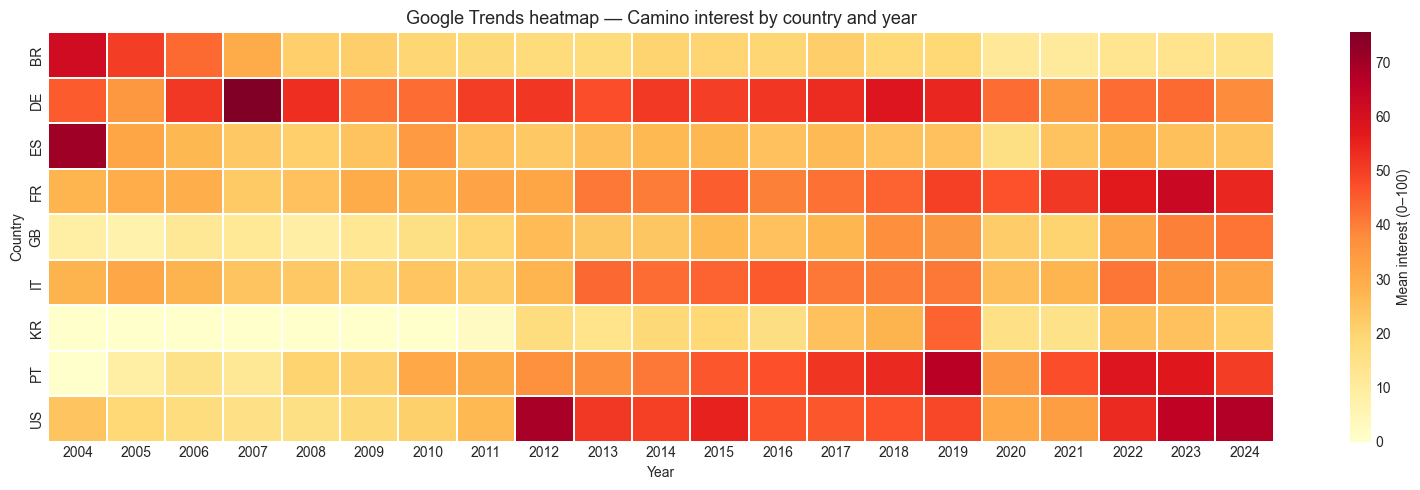

Figure saved → C:\Users\cello\Desktop\camino_datascience\reports\trends_heatmap.png


In [14]:
# Heatmap — country × year
pivot = trends_annual.pivot(index='geo', columns='year', values='interest_mean')

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    linewidths=0.3,
    annot=False,
    fmt='.0f',
    ax=ax,
    cbar_kws={'label': 'Mean interest (0–100)'}
)
ax.set_title('Google Trends heatmap — Camino interest by country and year')
ax.set_xlabel('Year')
ax.set_ylabel('Country')
plt.tight_layout()

fig_path2 = PROJECT_ROOT / 'reports' / 'trends_heatmap.png'
plt.savefig(fig_path2, dpi=150)
plt.show()
print(f"Figure saved → {fig_path2}")

### 1.5 First observations

*Notes (completed after running — 2004–2024 collection, 9 countries):*

**General trend**: Structural growth confirmed across all countries, with a clear
acceleration from 2012–2013 onward. Camino interest is not a stable phenomenon —
it has gained global visibility continuously over two decades.

**US (English-US) — notable isolated spike in 2012**: Strong peak well ahead of
the general trend. Likely linked to the wide distribution of the film *The Way*
(released 2010, broader reach 2011–2012). The one-year lag is typical of
deferred notoriety effects. → To cross-check against Oficina data on US pilgrim
counts in 2012–2013. Strong candidate signal for Axis B.

**DE (German) — isolated peak in 2007**: Spike appears before all other countries.
Likely linked to a major German book or TV documentary published that year.
Germany is historically one of the most consistent non-Spanish pilgrim-sending
countries. → Requires investigation (Axis B media event database).

**KR (Korean) — near-zero before 2011, then steady linear growth to 2019**:
No single triggering event visible — suggests a gradual cultural diffusion rather
than one media spike. Consistent with official Oficina data showing an explosion
of Korean pilgrims from 2012 onward. Linear profile is distinct from other
countries and worth modelling separately in Axis B.

**COVID 2020**: Dip visible across all 9 countries without exception — confirms
data consistency. Post-COVID rebound (2021–2022) is strongest for US, FR and PT.

**FR (French) — accelerating post-2021**: Steady growth with a sharp acceleration
in 2023–2024, reaching the highest recorded values for France in the dataset.
Consistent with growth observed on French routes. → Strong signal for Axis C
(geographic diversification toward French routes).

**PT (Portuguese) — double peak structure**: Clear peak in 2019, second peak in
2024. The 2019 peak aligns with the documented explosion of the Camino Portugués.
→ To cross-check against Oficina route-level data. Relevant for Axis C.

**ES (Spanish) — high in 2004–2005 then declining relative index**: Paradoxical
given Spain is the primary pilgrim-sending country. Likely a normalisation
artefact — Spanish interest was already high in 2004 (index baseline), so
relative growth appears lower. Absolute pilgrim numbers from Oficina will be
more meaningful for Spain than Trends data.

**Heatmap reading**: US (2012), DE (2007) and ES (2004–2005) stand out as
localised anomalies to be explained by media events. KR row clearly shows the
yellow→orange→red transition across 2011–2019. All countries show a white/light
gap in 2020 (COVID) followed by recovery.

---
## Section 2 — Oficina del Peregrino
🔲 *To be built in next session — requires manual PDF download first.*

**Preparation steps before next session:**
1. Go to https://oficinadelperegrino.com/estadisticas/
2. Download all annual PDF reports from 2004 to 2024
3. Save them in `data/raw/oficina/` with naming convention: `YYYY_oficina.pdf`

We will then use `pdfplumber` to extract the tables automatically.

---
## Section 3 — Bureau SJPDP (Saint-Jean-Pied-de-Port)
🔲 *To be built after Section 2.*

---
## Section 4 — Trail du Saint-Jacques (LiveTrail)
🔲 *To be built after Section 2.*

---
## Section 5 — ERA5 Climate data
🔲 *Requires Copernicus CDS account — see DATA_SOURCES.md for registration link.*